# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [1]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset

# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [2]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="../data")
df = ds.to_pandas()

## Lectura de Datos

In [3]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,NaN,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,NaN,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,NaN,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,NaN,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,NaN,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,NaN,Vox


In [4]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   idx          30213 non-null  int64
 1   article_idx  30213 non-null  int64
 2   date         30213 non-null  str  
 3   year         30213 non-null  str  
 4   month        30213 non-null  str  
 5   day          30213 non-null  str  
 6   author       18808 non-null  str  
 7   title        30213 non-null  str  
 8   article      29037 non-null  str  
 9   url          30072 non-null  str  
 10  section      19981 non-null  str  
 11  publication  30072 non-null  str  
dtypes: int64(2), str(10)
memory usage: 96.1 MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [5]:
# Análisis simple de datos faltantes por columna
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "faltantes": missing_count,
    "porcentaje": missing_pct
}).sort_values("faltantes", ascending=False)

print("Datos faltantes por columna:")
print(missing_summary)

# Chequeo rápido de calidad de datos: filas duplicadas completas
duplicadas = df.duplicated().sum()
print(f"\nFilas duplicadas completas: {duplicadas}")


Datos faltantes por columna:
             faltantes  porcentaje
author           11405       37.75
section          10232       33.87
article           1176        3.89
url                141        0.47
publication        141        0.47
idx                  0        0.00
article_idx          0        0.00
date                 0        0.00
year                 0        0.00
month                0        0.00
day                  0        0.00
title                0        0.00

Filas duplicadas completas: 0


In [6]:
# Cantidad de artículos por medio de prensa
articles_per_publication = df["publication"].value_counts()
print(articles_per_publication)

# Tome los 5 medios con más artículos
top_5_publications = articles_per_publication.head(5).index.tolist()
df_top_5 = df[df["publication"].isin(top_5_publications)].copy()

print("\nTop 5 medios:")
print(top_5_publications)
print(f"Filas en df_top_5: {len(df_top_5)}")

publication
Reuters               9431
The New York Times    2840
CNBC                  2623
The Hill              2349
People                1528
CNN                   1446
Refinery 29           1236
Vice                  1154
Mashable              1045
Business Insider       660
The Verge              594
TechCrunch             568
TMZ                    552
Vox                    549
Axios                  538
Politico               518
Washington Post        468
Buzzfeed News          376
Gizmodo                329
Economist              303
Wired                  231
Fox News               227
Vice News              187
New Republic           145
Hyperallergic          123
New Yorker              52
Name: count, dtype: int64

Top 5 medios:
['Reuters', 'The New York Times', 'CNBC', 'The Hill', 'People']
Filas en df_top_5: 18771


## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

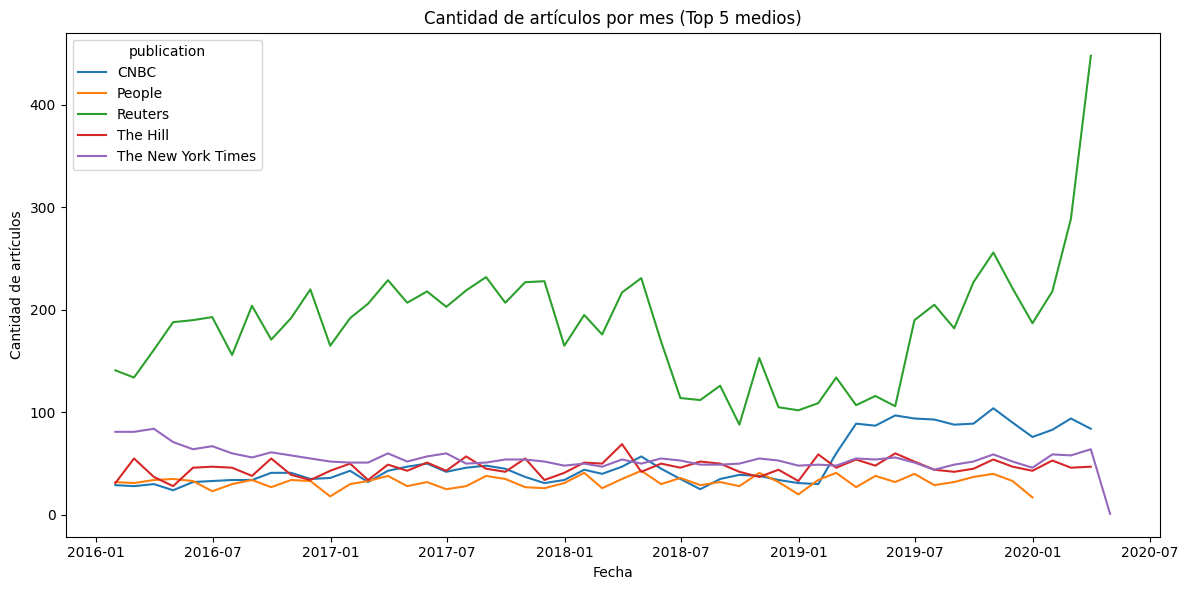

Medios incluidos en la gráfica: ['CNBC', 'People', 'Reuters', 'The Hill', 'The New York Times']


In [7]:
# Visualización simple de cantidad de artículos por mes y medio

# Convertimos fechas con tolerancia a formatos mixtos
# NOTA: en pandas reciente conviene usar format="mixed" cuando hay formatos distintos
# Sin esto perdemos algunos publication porque las fechas tienen formato distinto
df_top_5["date_parsed"] = pd.to_datetime(
    df_top_5["date"],
    format="mixed",
    errors="coerce"
)

# Nos quedamos con filas válidas de fecha
plot_df = df_top_5.dropna(subset=["date_parsed"]).copy()

# Agrupamos por fin de mes y medio de prensa (pandas nuevo: "ME")
articles_by_month = (
    plot_df
    .groupby([pd.Grouper(key="date_parsed", freq="ME"), "publication"])
    .size()
    .reset_index(name="articles")
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=articles_by_month,
    x="date_parsed",
    y="articles",
    hue="publication"
)

plt.title("Cantidad de artículos por mes (Top 5 medios)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de artículos")
plt.tight_layout()
plt.show()

print("Medios incluidos en la gráfica:", sorted(articles_by_month["publication"].unique().tolist()))

## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [8]:
def clean_text(df, column_name):

    # Rellenar faltantes para evitar errores en operaciones de texto
    result = df[column_name].fillna("")

    # Eliminar primeras palabras hasta el primer "\n"
    result = result.str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # Reemplazar signos de puntuación por espacio (versión simple)
    for punc in ["[", "]", "\n", ",", ".", ":", ";", "?", "!", "(", ")", '"', "'", "-"]:
        result = result.str.replace(punc, " ", regex=False)

    # Colapsar espacios múltiples
    result = result.str.replace(r"\s+", " ", regex=True).str.strip()

    return result

In [9]:
# Aplicamos clean_text sobre el cuerpo del artículo y guardamos en una nueva columna
# (también podría usarse "title" o combinar ambas columnas)
df_top_5["CleanText"] = clean_text(df_top_5, "article")

# Vista rápida para validar
print(df_top_5[["publication", "article", "CleanText"]].head(10))


           publication                                            article  \
0              Reuters  Feb 2 (Reuters) - Teva Pharmaceutical Industri...   
1                 CNBC  The head of the Centers for Medicare and Medic...   
2             The Hill  Benchmark, the venture capital firm that helpe...   
5                 CNBC  (Updates with new first paragraph, adds backgr...   
6              Reuters  TORONTO, Dec 4 (Reuters) - Bank of Montreal on...   
8   The New York Times  Calculator Sure, if you choose the right place...   
9   The New York Times  BOGOTÁ, Colombia — Colombia is investigating a...   
11            The Hill  Virginia Gov. Terry McAuliffe (D) included a d...   
12                CNBC  Italy's Finance Minister, Pier Carlo Padoan, h...   
13            The Hill  Former Starbucks CEO Howard Schultz has recrui...   

                                            CleanText  
0   feb 2 reuters teva pharmaceutical industries l...  
1   the head of the centers for medicare

## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

**Decisión:** conviene usar **principalmente el cuerpo del artículo** (`article`), y en la práctica del notebook ya se limpia esa columna.

**Por qué el cuerpo:** tiene mucho más texto que el título, así que refleja mejor el vocabulario y el estilo de cada medio.

**Por qué no solo el título:** el título es muy corto y depende mucho del tema del día; dos medios distintos pueden poner títulos parecidos sobre la misma noticia.

**Cuándo combinar título + cuerpo:** tiene sentido si queremos no perder información cuando falta parte del artículo (en el dataset hay filas sin `article`) o si el título aporta un matiz que no está en el primer párrafo. En ese caso se puede armar un solo texto, por ejemplo `title + " " + article`, y aplicar la misma limpieza.

**Cuidado:** si más adelante se clasifica por medio, hay que revisar que en el texto no queden “pistas fáciles” (nombre del diario, URL, firmas típicas), porque el modelo podría aprender eso en lugar del contenido real.

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [10]:
# Buscamos pistas directas simples: menciones al nombre de cada medio en el texto.
# Para hacerlo simple, usamos el texto limpio ya calculado en CleanText.

mentions = []

for publication in top_5_publications:
    name = publication.lower()
    count = df_top_5["CleanText"].str.contains(name, regex=False, na=False).sum()
    mentions.append({
        "medio_mencionado": publication,
        "articulos_que_lo_mencionan": count
    })

mentions_df = pd.DataFrame(mentions)
print(mentions_df)

# Miramos algunos ejemplos donde el propio medio aparece mencionado en el artículo.
for publication in top_5_publications:
    name = publication.lower()
    examples = df_top_5[
        (df_top_5["publication"] == publication) &
        (df_top_5["CleanText"].str.contains(name, regex=False, na=False))
    ][["publication", "CleanText", "title", "url"]].head(3)

    print("\nEjemplos para", publication)
    display(examples)

     medio_mencionado  articulos_que_lo_mencionan
0             Reuters                        9299
1  The New York Times                         722
2                CNBC                         961
3            The Hill                        2392
4              People                        5938

Ejemplos para Reuters


,publication,CleanText,title,url
0,Reuters,feb 2 reuters teva pharmaceutical industries l...,BRIEF-Teva Says Fremanezumab Marketing Authori...,https://www.reuters.com/article/brief-teva-say...
6,Reuters,toronto dec 4 reuters bank of montreal on tues...,Bank of Montreal's quarterly earnings beat mar...,https://www.reuters.com/article/bmo-results/ba...
15,Reuters,houston reuters an outage on a major pipeline ...,Crude market takes U.S. Seaway pipeline outage...,http://www.reuters.com/article/us-pipeline-ope...



Ejemplos para The New York Times


,publication,CleanText,title,url
8,The New York Times,calculator sure if you choose the right place ...,Are Beach House Rentals Profitable?,https://www.nytimes.com/2019/05/23/realestate/...
25,The New York Times,opinion the remnants of decades of conflict ar...,Opinion | When War Is More Dangerous for Civil...,https://www.nytimes.com/2018/03/07/opinion/the...
45,The New York Times,footsteps in and around stockholm the secretiv...,"In Search of Hilma af Klint, Who Upended Art H...",https://www.nytimes.com/2019/10/21/travel/stoc...



Ejemplos para CNBC


,publication,CleanText,title,url
12,CNBC,italy s finance minister pier carlo padoan has...,Bailout for Italian banks has been 'absolutely...,https://www.cnbc.com/2016/09/02/weak-global-gr...
49,CNBC,the kremlin said on wednesday it was total non...,Kremlin says it has no compromising dossier on...,https://www.cnbc.com/2017/01/11/kremlin-says-i...
146,CNBC,lyft s week is off to a dreary start as the st...,Lyft's stock continues to dive after its disma...,https://www.cnbc.com/2019/04/15/lyfts-stock-co...



Ejemplos para The Hill


,publication,CleanText,title,url
2,The Hill,benchmark the venture capital firm that helped...,Uber investor accuses Kalanick of 'undermining...,https://thehill.com/policy/technology/346520-u...
11,The Hill,virginia gov terry mcauliffe d included a dig ...,McAuliffe jabs Pence over GOP healthcare bill ...,https://thehill.com/homenews/senate/342124-vir...
13,The Hill,former starbucks ceo howard schultz has recrui...,Schultz recruiting GOP insiders ahead of possi...,https://thehill.com/homenews/campaign/432954-s...



Ejemplos para People


,publication,CleanText,title,url
59,People,nearly $100 000 in jewelry that once belonged ...,Bernie and Ruth Madoff's Antique Jewelry Being...,https://people.com/crime/bernie-and-ruth-madof...
89,People,a doctor’s visit is no big deal when you’ve go...,Chip Gaines and Son Share Heartwarming Smile a...,https://people.com/parents/joanna-gaines-chip-...
167,People,posh spice still has the moves former pop star...,Victoria Beckham Dances with Cast of Tina: The...,https://people.com/style/watch-victoria-beckha...


In [11]:
# Analisis un poco mas completo de posibles pistas directas del medio.
# La idea es mirar URLs, firmas/autores, secciones y textos repetidos.

from urllib.parse import urlparse

# 1) URLs: el dominio suele identificar directamente al medio.
df_top_5["url_domain"] = df_top_5["url"].fillna("").apply(
    lambda x: urlparse(x).netloc.replace("www.", "") if x else ""
)

print("Dominios mas frecuentes por medio:")
for publication in top_5_publications:
    print("\n", publication)
    display(
        df_top_5[df_top_5["publication"] == publication]["url_domain"]
        .value_counts()
        .head(5)
        .reset_index(name="cantidad")
        .rename(columns={"url_domain": "dominio"})
    )

# 2) Firmas/autores: algunas firmas pueden ser muy propias de un medio.
print("\nAutores mas frecuentes por medio:")
for publication in top_5_publications:
    print("\n", publication)
    display(
        df_top_5[df_top_5["publication"] == publication]["author"]
        .fillna("SIN AUTOR")
        .value_counts()
        .head(10)
        .reset_index(name="cantidad")
        .rename(columns={"author": "autor"})
    )

# 3) Secciones: si una seccion aparece solo en un medio, tambien puede ser una pista.
print("\nSecciones mas frecuentes por medio:")
for publication in top_5_publications:
    print("\n", publication)
    display(
        df_top_5[df_top_5["publication"] == publication]["section"]
        .fillna("SIN SECCION")
        .value_counts()
        .head(10)
        .reset_index(name="cantidad")
        .rename(columns={"section": "seccion"})
    )

# 4) Plantillas repetidas: miramos comienzos repetidos de articulos.
# Esto no detecta todos los casos, pero sirve para encontrar frases tipo firma o formato fijo.
df_top_5["article_start"] = (
    df_top_5["article"]
    .fillna("")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str[:120]
)

repeated_starts = (
    df_top_5[df_top_5["article_start"] != ""]
    .groupby(["publication", "article_start"])
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

print("\nComienzos de articulos repetidos mas frecuentes:")
display(repeated_starts[repeated_starts["cantidad"] > 1].head(20))


Dominios mas frecuentes por medio:

 Reuters


,dominio,cantidad
0,reuters.com,9431



 The New York Times


,dominio,cantidad
0,nytimes.com,2794
1,cn.nytimes.com,9
2,learning.blogs.nytimes.com,6
3,wordplay.blogs.nytimes.com,5
4,artsbeat.blogs.nytimes.com,5



 CNBC


...

,seccion,cantidad
0,SIN SECCION,2349



 People


,seccion,cantidad
0,tv,280
1,movies,153
2,style,136
3,crime,130
4,celebrity,112
5,music,100
6,royals,83
7,parents,72
8,pets,67
9,food,60



Comienzos de articulos repetidos mas frecuentes:


,publication,article_start,cantidad
15310,The Hill,View the discussion thread. The Hill 1625 K St...,51
14495,The Hill,President TrumpDonald John TrumpFacebook relea...,38
14505,The Hill,President TrumpDonald John TrumpTrump pushes b...,37
3532,People,"PEOPLE Now airs live, Monday through Friday, f...",18
13798,The Hill,Democratic strategist Antjuan Seawright said T...,14
13819,The Hill,Donald TrumpDonald John TrumpPossible GOP chal...,13
14750,The Hill,Senate Majority Leader Mitch McConnellAddison ...,9
14052,The Hill,Hillary ClintonHillary Diane Rodham ClintonTop...,9
14051,The Hill,Hillary ClintonHillary Diane Rodham ClintonLew...,8
14705,The Hill,Sen. Elizabeth WarrenElizabeth Ann WarrenHarry...,8


Los datos revelan varias pistas directas de identificación del medio en el texto:

**1. Dateline de Reuters (la más fuerte)**
Casi el 100% de los artículos de Reuters (9.299 de 9.431) contienen la palabra "reuters" en el cuerpo del texto, debido a la plantilla `LUGAR, Fecha (Reuters) —` que encabeza cada nota. Es una firma estructural que permitiría identificar el medio con una sola regla simple.

**2. URLs**
El campo `url` contiene el dominio del medio (`reuters.com`, `nytimes.com`, `cnbc.com`, etc.), lo que permite identificar el origen con exactitud perfecta. No afecta el texto del artículo, pero sería data leakage si se usara como feature.

**3. Nombre del medio en el texto**
Además de Reuters, The Hill aparece en 2.392 artículos y CNBC en 961. People suma 5.938 menciones, aunque "people" es una palabra muy común en inglés y la mayoría de esas ocurrencias no refieren al medio.

**4. Plantillas repetidas**
The Hill tiene artículos con encabezados de newsletter repetidos decenas de veces ("Welcome to Hillicon Valley", "Welcome to OVERNIGHT CYBERSECURITY", "To view past editions of The Hill's 12:30 Report"), y People tiene plantillas del tipo "PEOPLE Now airs live, Monday through Friday". Estos comienzos identifican el medio de forma casi perfecta.

**5. Secciones y autores**
Las secciones son propias de cada medio (The Hill no tiene sección definida en ningún artículo; las secciones de People como "royals" o "pets" son exclusivas de ese medio). Algunos autores también publican exclusivamente en un solo outlet.

**¿Conviene eliminarlas?**

Sí. Si el objetivo es clasificar por estilo o contenido editorial real, mantener estas pistas haría que el clasificador aprenda atajos triviales en lugar de diferencias genuinas de lenguaje o enfoque temático. El modelo tendría alta accuracy pero sin generalización ni valor analítico.

Las acciones concretas recomendadas son:
- Eliminar el dateline de Reuters con una regex del tipo `^[A-Z ,\d]+ \(Reuters\)[^—]*—\s*`
- No usar las columnas `url`, `section` ni `author` como features
- Eliminar o normalizar los encabezados de newsletter repetidos de The Hill y People
- Evaluar filtrar ocurrencias del nombre exacto del medio en el texto, con cuidado de no eliminar usos legítimos de palabras comunes como "people"

## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

**Restricción por sección temática**

La motivación es clara: si Reuters publica mayormente noticias financieras y People publica exclusivamente contenido de celebridades, un clasificador podría aprender a distinguir los medios simplemente por el tema, sin capturar diferencias reales de estilo o vocabulario editorial.

Sin embargo, la restricción por sección presenta problemas prácticos importantes con estos datos:

- **The Hill no tiene sección en ningún artículo** (el campo `section` es `NaN` en los 2.349 artículos). Aplicar un filtro por sección lo excluiría completamente del análisis.
- Las secciones **no son comparables entre medios**: la sección "Business News" de Reuters no equivale a "Markets" de CNBC ni a "business" del NYT. No existe un esquema de secciones compartido.
- El campo `section` tiene un 33.87% de valores faltantes en el dataset general, lo que limita aún más la cobertura.

Una alternativa parcial sería definir secciones temáticas propias (por ejemplo, agrupando por palabras clave del título), pero eso requiere trabajo adicional y decisiones arbitrarias.

**Restricción por período temporal**

Acotar el análisis a un rango de fechas específico reduce el riesgo de que eventos puntuales (elecciones, pandemias, crisis financieras) dominen el vocabulario de ciertos medios en ciertos momentos. También garantiza que todos los medios estén cubriendo los mismos eventos del mundo.

La desventaja principal es la reducción del tamaño del dataset, que ya es moderado. Además, algunos medios pueden tener cobertura más esparsa en ciertos períodos, generando desbalance entre clases.

**Conclusión**

Ninguna de las dos restricciones es sencilla de aplicar con estos datos tal como están. La restricción temporal es más viable porque no depende de metadatos inconsistentes, pero implica aceptar menor volumen de datos. La restricción por sección requeriría primero construir una taxonomía temática propia, lo cual escapa al alcance de esta etapa exploratoria. En la práctica, una estrategia razonable sería combinar ambas parcialmente: seleccionar un período de superposición donde todos los medios tengan cobertura comparable, y monitorear si los temas dominantes varían mucho entre medios dentro de ese período.

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

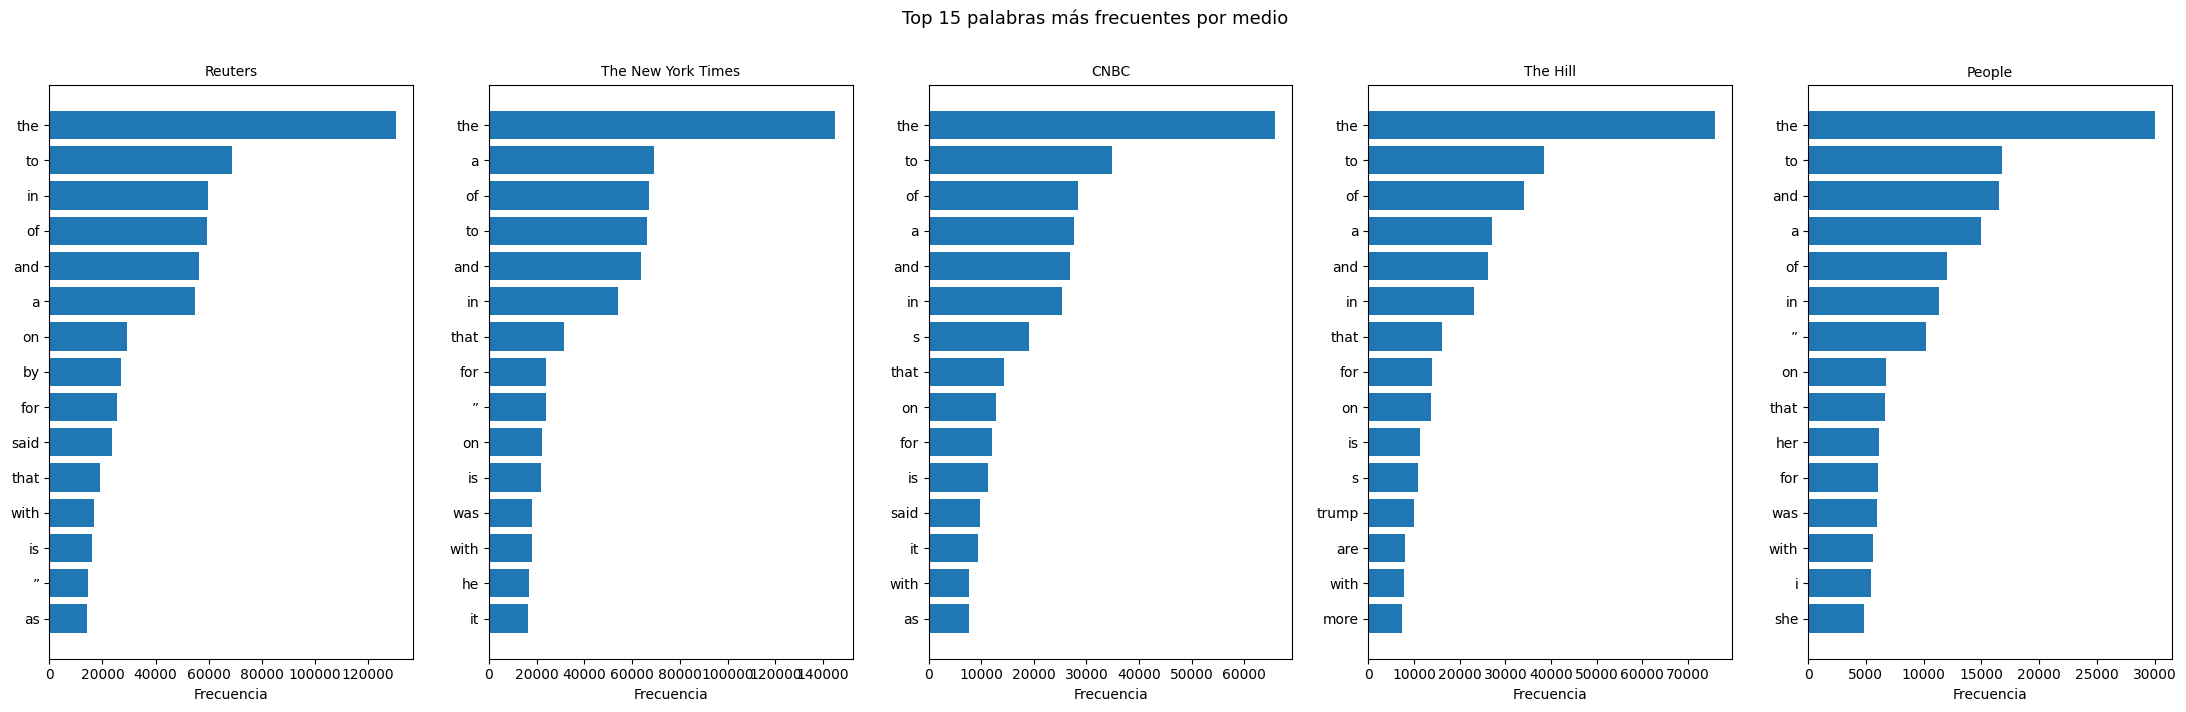

In [12]:
from collections import Counter

TOP_N = 15

fig, axes = plt.subplots(1, 5, figsize=(22, 7))

for ax, publication in zip(axes, top_5_publications):
    texts = df_top_5[df_top_5["publication"] == publication]["CleanText"]
    all_words = " ".join(texts).split()
    word_counts = Counter(all_words).most_common(TOP_N)
    words, counts = zip(*word_counts)

    ax.barh(list(words)[::-1], list(counts)[::-1])
    ax.set_title(publication, fontsize=10)
    ax.set_xlabel("Frecuencia")

plt.suptitle(f"Top {TOP_N} palabras más frecuentes por medio", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Problema encontrado: dominancia de stop words**

Las palabras más frecuentes en todos los medios son prácticamente idénticas: artículos, preposiciones y pronombres del inglés ("the", "to", "a", "of", "in", "and", "that", "said", etc.). Estas palabras no aportan información discriminativa entre medios y ocultan las diferencias reales de vocabulario.

**Ideas para mejorar la visualización sin implementar:**

1. **Eliminar stop words**: filtrar una lista estándar (por ejemplo, la de NLTK o scikit-learn) antes de contar. Esto haría visibles las palabras con contenido semántico real.

2. **Usar TF-IDF en lugar de frecuencia cruda**: ponderar cada palabra por qué tan exclusiva es de un medio respecto al resto. Así se destacarían términos característicos de cada outlet (e.g., "reuters" para Reuters, "trump" para The Hill, nombres de famosos para People) en lugar de palabras universales.

3. **Restringir por sección o fecha**: mostrar el top de palabras solo para un subconjunto de artículos (una sección temática o un período), para ver si el vocabulario distintivo cambia según el contexto.

4. **Comparar títulos vs. cuerpos**: generar la misma visualización separada para `title` y `article`, para ver si el estilo léxico difiere entre ambos campos por medio.

## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

          publication  total_palabras  promedio_por_articulo  articulos
0  The New York Times         2630560             926.253521       2840
1             Reuters         2605551             276.275156       9431
2            The Hill         1390327             591.880375       2349
3                CNBC         1254102             478.117423       2623
4              People          644466             421.770942       1528


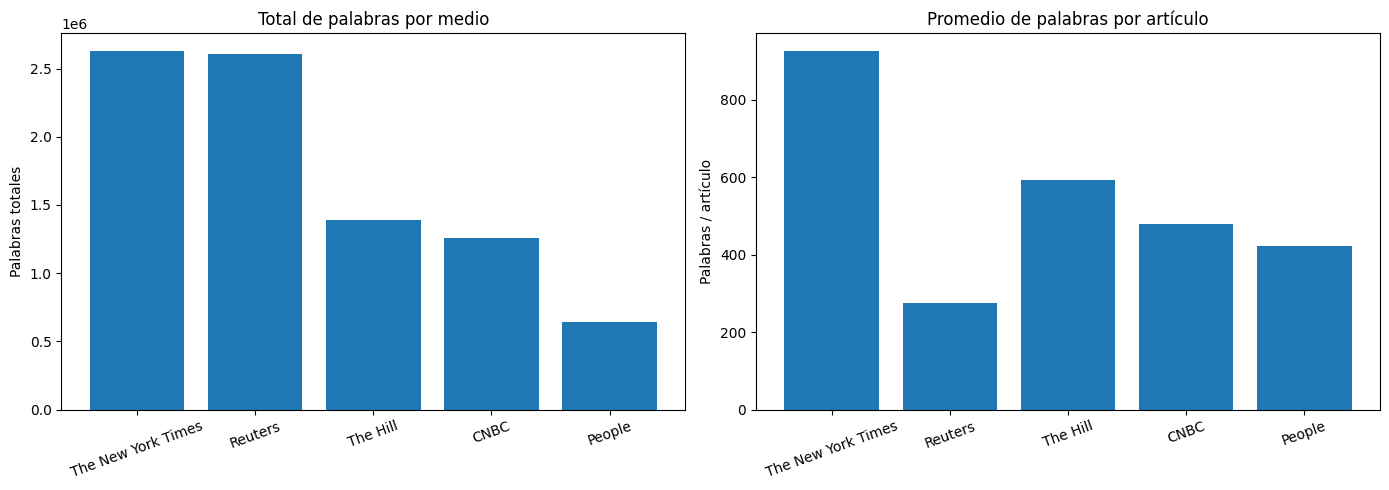

In [13]:
# Conteo de palabras por artículo
df_top_5["word_count"] = df_top_5["CleanText"].str.split().str.len()

# Total de palabras y promedio por artículo para cada medio
word_stats = (
    df_top_5.groupby("publication")["word_count"]
    .agg(total_palabras="sum", promedio_por_articulo="mean", articulos="count")
    .sort_values("total_palabras", ascending=False)
    .reset_index()
)
print(word_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: total de palabras por medio
axes[0].bar(word_stats["publication"], word_stats["total_palabras"])
axes[0].set_title("Total de palabras por medio")
axes[0].set_ylabel("Palabras totales")
axes[0].tick_params(axis="x", rotation=20)

# Gráfico 2: promedio de palabras por artículo
axes[1].bar(word_stats["publication"], word_stats["promedio_por_articulo"])
axes[1].set_title("Promedio de palabras por artículo")
axes[1].set_ylabel("Palabras / artículo")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Problema: el total de palabras está sesgado por el número de artículos**

Si se mide solo el total acumulado, Reuters domina ampliamente por volumen (9.431 artículos vs. ~1.500–2.800 de los demás), no necesariamente porque sus artículos sean más extensos. Esto hace que la comparación sea poco informativa sobre el estilo de cada medio.

La métrica más relevante es el **promedio de palabras por artículo**, que permite comparar la extensión típica independientemente del tamaño del dataset. Con esa normalización pueden aparecer diferencias más significativas: por ejemplo, artículos de opinión del NYT suelen ser más largos que despachos de agencia de Reuters, y notas de People suelen ser más cortas.

**Formas de resolver o complementar:**

- Usar el promedio (o mediana, más robusta a outliers) de palabras por artículo como métrica principal.
- Complementar con un boxplot o violinplot para ver la distribución completa, no solo la media, ya que algunos medios pueden tener alta varianza (mezcla de noticias breves y artículos largos).
- Normalizar también por caracteres en lugar de palabras, para evitar que artículos con muchas palabras cortas inflen el conteo.

## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

                    Reuters  The New York Times  CNBC  The Hill  People
Reuters                8358                  29    31         5    1517
The New York Times       45                 482    13        37    1599
CNBC                    821                  46   901         7     812
The Hill                 71                 127    13      2335     969
People                    4                  38     3         8    1041


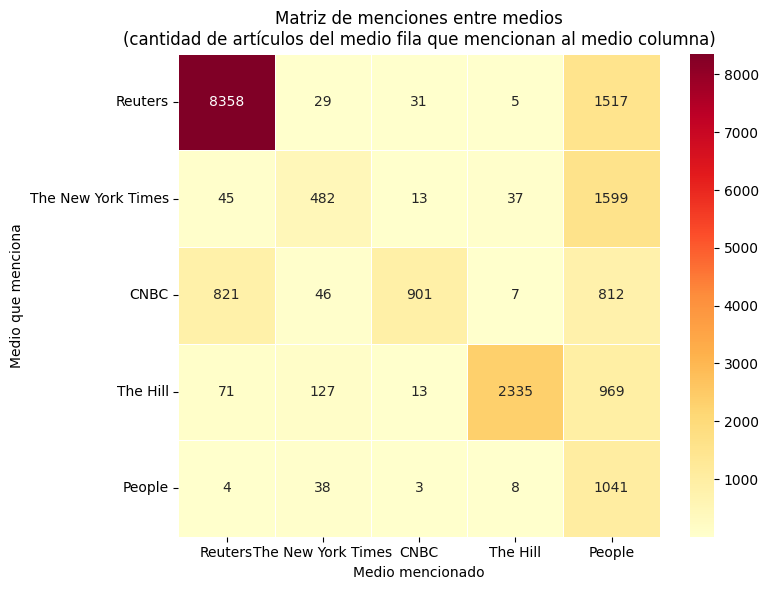

In [14]:
# Matriz 5x5 de menciones: entry (i,j) = cuántos artículos del medio i mencionan al medio j
mentions_matrix = pd.DataFrame(0, index=top_5_publications, columns=top_5_publications)

for source in top_5_publications:
    source_texts = df_top_5[df_top_5["publication"] == source]["CleanText"]
    for target in top_5_publications:
        count = source_texts.str.contains(target.lower(), regex=False, na=False).sum()
        mentions_matrix.loc[source, target] = count

print(mentions_matrix)

# Heatmap de la matriz
plt.figure(figsize=(8, 6))
sns.heatmap(
    mentions_matrix,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
)
plt.title("Matriz de menciones entre medios\n(cantidad de artículos del medio fila que mencionan al medio columna)")
plt.ylabel("Medio que menciona")
plt.xlabel("Medio mencionado")
plt.tight_layout()
plt.show()

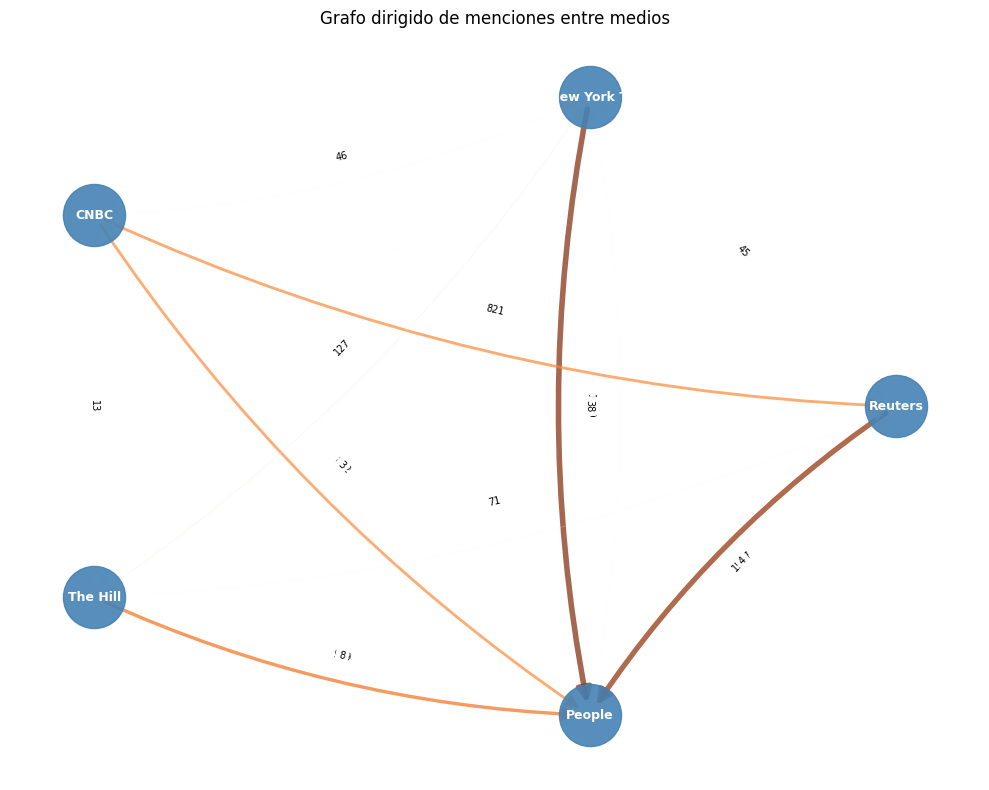

In [16]:
G = nx.DiGraph()
G.add_nodes_from(top_5_publications)

for source in top_5_publications:
    for target in top_5_publications:
        if source != target:
            weight = mentions_matrix.loc[source, target]
            if weight > 0:
                G.add_edge(source, target, weight=weight)

weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w = max(weights)

plt.figure(figsize=(10, 8))
pos = nx.circular_layout(G)

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="steelblue", alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold")
nx.draw_networkx_edges(
    G, pos,
    width=[4 * w / max_w for w in weights],
    alpha=0.7,
    edge_color=weights,
    edge_cmap=plt.cm.Oranges,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.1",
)
edge_labels = {(u, v): G[u][v]["weight"] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title("Grafo dirigido de menciones entre medios")
plt.axis("off")
plt.tight_layout()
plt.show()

**Observaciones sobre la matriz de menciones**

La columna de **People** está inflada artificialmente: "people" es una palabra extremadamente común en inglés, por lo que prácticamente cualquier artículo la contiene, independientemente de si refiere al medio de prensa. Esto distorsiona tanto la fila (People menciona a otros) como la columna (otros mencionan a People). Para obtener un conteo más preciso habría que buscar la frase exacta con mayúscula o en contextos específicos (e.g., `"People magazine"`, `"people.com"`).

La fila de **Reuters** tiende a tener conteos altos en todas las columnas simplemente porque tiene casi cuatro veces más artículos que los demás medios. Para comparar la "propensión" a mencionar otros medios de forma más justa, convendría normalizar por el número de artículos de cada fila (es decir, expresar la entrada (i,j) como fracción de artículos del medio i, en lugar del conteo bruto).

A pesar de estas limitaciones, el heatmap y el grafo permiten ver qué medios son más referenciados por otros en términos absolutos, y si existen relaciones asimétricas (por ejemplo, si The Hill menciona al NYT mucho más de lo que el NYT menciona a The Hill).

## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

1. **¿Qué tan bien se puede adivinar el medio de prensa solo leyendo el texto?**  
   *Camino posible:* armar un conjunto de entrenamiento y prueba a partir de `CleanText` (o título + cuerpo), vectorizar con bolsa de palabras o TF-IDF, y probar un clasificador simple (por ejemplo regresión logística o Naive Bayes). Comparar accuracy usando solo título, solo cuerpo, o ambos.

2. **¿Los medios cubren los mismos temas al mismo tiempo o cada uno tiene “olas” distintas?**  
   *Camino posible:* agrupar artículos por mes o por año, y para cada medio contar frecuencias de palabras o de la columna `section` (donde no falte). Graficar series temporales o mapas de calor medio × tiempo para ver si hay picos comunes (crisis, elecciones) o picos propios de un solo outlet.

3. **¿Qué tan “parecidos” son dos medios en el vocabulario que usan?**  
   *Camino posible:* a partir de los conteos de palabras por medio, medir similitud entre vectores de frecuencias o TF-IDF (por ejemplo coseno entre medios). Interpretar qué pares quedan más cerca y si coincide con el tipo de noticia (economía, política, espectáculos, etc.).
